In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Class counts (1000-row slice):
 Score
1     98
2     47
3     75
4    138
5    642
Name: count, dtype: int64


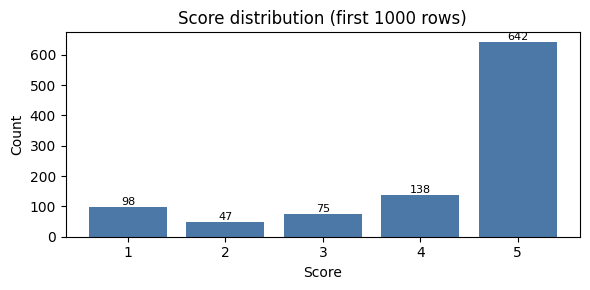

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 186ms/step - accuracy: 0.3114 - loss: 1.6103 - val_accuracy: 0.3800 - val_loss: 1.6031
Epoch 2/3
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.5343 - loss: 1.6031 - val_accuracy: 0.4067 - val_loss: 1.6014
Epoch 3/3
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6700 - loss: 1.5963 - val_accuracy: 0.4133 - val_loss: 1.5996

Test: loss=1.5980 acc=0.4667

Classification report:
              precision    recall  f1-score   support

           1       0.22      0.33      0.26        15
           2       0.00      0.00      0.00         7
           3       0.25      0.09      0.13        11
           4       0.22      0.33      0.26        21
           5       0.75      0.59      0.66        96

    accuracy                           0.47       150
   macro avg       0.29      0.27      0.26       150
weighted avg       0.55      0.47      0.50       150


Confusion matrix:
        pred_1  pred_2  pred_3  pred_4  pred_5
true_1       5    

In [3]:
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt, tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, utils

# ======= fast, simple settings =======
CSV = "//content//drive//MyDrive//Day1//amazon_review.csv"      # file path
SEED = 42; np.random.seed(SEED); tf.random.set_seed(SEED)
N_ROWS = 1000            # <-- use 1000 lines only
MAX_WORDS = 12000        # vocab cap
MAX_LEN = 60             # pad/truncate length
EMBED = 64               # embedding dims
LSTM_UNITS = 48          # small LSTM
EPOCHS = 3               # quick train
BATCH = 256

# ======= load & pick columns =======
df = pd.read_csv(CSV, engine="python")
tcands = ["Text","text","review_text","review","body"]
scands = ["Score","score","rating","stars","label"]
tcol = next((c for c in tcands if c in df.columns), None)
scol = next((c for c in scands if c in df.columns), None)
if tcol is None or scol is None:
    raise ValueError(f"Text/Score columns not found. Got: {df.columns.tolist()}")

# ======= clean, keep 1000 rows =======
clean = lambda s: re.sub(r"\s+"," ", re.sub(r"<.*?>"," ", str(s))).strip().lower()
df = df[[tcol, scol]].dropna()
df[scol] = pd.to_numeric(df[scol], errors="coerce")
df = df.dropna().astype({scol:int})
df[tcol] = df[tcol].map(clean)
df = df.iloc[:N_ROWS].reset_index(drop=True)

# ======= show imbalance (counts + bar) =======
counts = df[scol].value_counts().sort_index()
print("Class counts (1000-row slice):\n", counts)
plt.figure(figsize=(6,3)); plt.bar(counts.index, counts.values, color="#4C78A8")
plt.title("Score distribution (first 1000 rows)"); plt.xlabel("Score"); plt.ylabel("Count")
for x,v in zip(counts.index, counts.values): plt.text(x, v, str(v), ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()

# ======= split =======
X = df[tcol].values; y = df[scol].values
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.30, random_state=SEED, stratify=y)
X_va, X_te, y_va, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

# ======= tokenize & pad =======
tok = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>"); tok.fit_on_texts(X_tr)
to_pad = lambda X: pad_sequences(tok.texts_to_sequences(X), maxlen=MAX_LEN, padding="post", truncating="post")
X_tr, X_va, X_te = to_pad(X_tr), to_pad(X_va), to_pad(X_te)

# ======= labels (categorical) =======
classes = np.sort(np.unique(y))
c2i = {c:i for i,c in enumerate(classes)}
y_tr_i = np.array([c2i[v] for v in y_tr]); y_va_i = np.array([c2i[v] for v in y_va]); y_te_i = np.array([c2i[v] for v in y_te])
C = len(classes)
y_tr_oh = utils.to_categorical(y_tr_i, C); y_va_oh = utils.to_categorical(y_va_i, C); y_te_oh = utils.to_categorical(y_te_i, C)

# ======= compact model =======
model = models.Sequential([
    layers.Embedding(input_dim=min(MAX_WORDS, len(tok.word_index))+1, output_dim=EMBED,
                     input_length=MAX_LEN, mask_zero=True),
    layers.SpatialDropout1D(0.1),
    layers.LSTM(LSTM_UNITS),
    layers.Dense(C, activation="softmax")
])
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

# ======= class weights & train =======
cw = compute_class_weight(class_weight="balanced", classes=np.arange(C), y=y_tr_i)
cw = {i:w for i,w in enumerate(cw)}
model.fit(X_tr, y_tr_oh, validation_data=(X_va, y_va_oh), epochs=EPOCHS, batch_size=BATCH,
          class_weight=cw, verbose=1)

# ======= evaluate =======
loss, acc = model.evaluate(X_te, y_te_oh, verbose=0)
print(f"\nTest: loss={loss:.4f} acc={acc:.4f}")
pred = model.predict(X_te, verbose=0).argmax(1)

print("\nClassification report:")
print(classification_report(y_te_i, pred, target_names=[str(c) for c in classes]))

print("\nConfusion matrix:")
print(pd.DataFrame(confusion_matrix(y_te_i, pred),
                   index=[f"true_{c}" for c in classes],
                   columns=[f"pred_{c}" for c in classes]))

# ======= quick sanity predictions =======
samples = ["Amazing quality, highly recommend!", "Awful, totally disappointed.", "Decent value for the price."]
s_pad = to_pad(samples)
s_pred = model.predict(s_pad, verbose=0).argmax(1)
inv = {v:k for k,v in c2i.items()}
print("\nSample predictions:")
for s, p in zip(samples, s_pred): print(f"- {s}  => predicted Score: {inv[p]}")

Class counts (first 20,000 rows):
 Score
1     1824
2     1120
3     1649
4     2836
5    12571
Name: count, dtype: int64


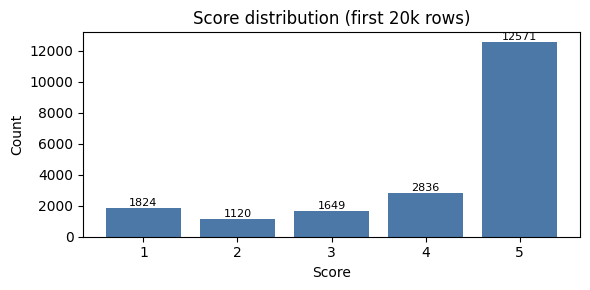

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/4
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.4151 - loss: 1.5191 - val_accuracy: 0.5910 - val_loss: 1.1963
Epoch 2/4
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5928 - loss: 1.2373 - val_accuracy: 0.5060 - val_loss: 1.2299
Epoch 3/4
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6339 - loss: 1.0375 - val_accuracy: 0.4000 - val_loss: 1.4301

Test: loss=1.2262  acc=0.5753

Classification report:
              precision    recall  f1-score   support

           1       0.30      0.74      0.43       273
           2       0.16      0.03      0.05       168
           3       0.21      0.21      0.21       247
           4       0.22      0.14      0.17       426
           5       0.80      0.75      0.77      1886

    accuracy                           0.58      3000
   macro avg       0.34      0.37      0.32      3000
weighted avg       0.58      0.58      0.57      3000


Confusion matrix:
        pred_1  pred_2  pred_3  pred_4  pred_5
true_1     2

In [4]:
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt, tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, utils

# ======= config =======
#CSV = "Reviews.csv"    # path to your file
# CSV = "D:\\HardDriveFiles\\Personal\\REVA\\RACE\\Semester1\\DATASETS\\DeepLearning\\Day1\\amazon_review.csv"
CSV = "//content//drive//MyDrive//Day1//amazon_review.csv"
SEED = 42; np.random.seed(SEED); tf.random.set_seed(SEED)
N_ROWS = 20000         # <-- use exactly 20k rows
MAX_WORDS = 20000      # vocab cap (speed vs. coverage)
MAX_LEN = 90           # pad/truncate length
EMBED = 100            # embedding dims
LSTM_UNITS = 64        # units per LSTM layer
EPOCHS = 4             # quick training
BATCH = 256

# ======= load & detect columns =======
df = pd.read_csv(CSV, engine="python")
tcands = ["Text","text","review_text","review","body"]
scands = ["Score","score","rating","stars","label"]
tcol = next((c for c in tcands if c in df.columns), None)
scol = next((c for c in scands if c in df.columns), None)
if tcol is None or scol is None:
    raise ValueError(f"Text/Score columns not found. Available: {df.columns.tolist()}")

# ======= clean, filter to 20k =======
clean = lambda s: re.sub(r"\s+"," ", re.sub(r"<.*?>"," ", str(s))).strip().lower()
df = df[[tcol, scol]].dropna()
df[scol] = pd.to_numeric(df[scol], errors="coerce")
df = df.dropna().astype({scol:int})
df[tcol] = df[tcol].map(clean)
df = df.head(N_ROWS).reset_index(drop=True)

# ======= imbalance (counts + bar) =======
counts = df[scol].value_counts().sort_index()
print("Class counts (first 20,000 rows):\n", counts)
plt.figure(figsize=(6,3)); plt.bar(counts.index, counts.values, color="#4C78A8")
plt.title("Score distribution (first 20k rows)"); plt.xlabel("Score"); plt.ylabel("Count")
for x,v in zip(counts.index, counts.values): plt.text(x, v, str(v), ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()

# ======= split =======
X = df[tcol].values; y = df[scol].values
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.30, random_state=SEED, stratify=y)
X_va, X_te, y_va, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

# ======= tokenize & pad =======
tok = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>"); tok.fit_on_texts(X_tr)
to_pad = lambda X: pad_sequences(tok.texts_to_sequences(X), maxlen=MAX_LEN, padding="post", truncating="post")
X_tr, X_va, X_te = to_pad(X_tr), to_pad(X_va), to_pad(X_te)

# ======= labels to categorical =======
classes = np.sort(np.unique(y)); c2i = {c:i for i,c in enumerate(classes)}
y_tr_i = np.array([c2i[v] for v in y_tr]); y_va_i = np.array([c2i[v] for v in y_va]); y_te_i = np.array([c2i[v] for v in y_te])
C = len(classes)
y_tr_oh = utils.to_categorical(y_tr_i, C); y_va_oh = utils.to_categorical(y_va_i, C); y_te_oh = utils.to_categorical(y_te_i, C)

# ======= 3-layer LSTM model =======
model = models.Sequential([
    layers.Embedding(input_dim=min(MAX_WORDS, len(tok.word_index))+1, output_dim=EMBED,
                     input_length=MAX_LEN, mask_zero=True),
    layers.SpatialDropout1D(0.2),
    layers.LSTM(LSTM_UNITS, return_sequences=True),
    layers.LSTM(LSTM_UNITS, return_sequences=True),
    layers.LSTM(LSTM_UNITS),
    layers.Dense(C, activation="softmax")
])
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

# ======= handle imbalance & train =======
cw = compute_class_weight(class_weight="balanced", classes=np.arange(C), y=y_tr_i)
cw = {i:w for i,w in enumerate(cw)}
model.fit(X_tr, y_tr_oh, validation_data=(X_va, y_va_oh), epochs=EPOCHS, batch_size=BATCH,
          class_weight=cw, verbose=1,
          callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", mode="max", patience=2, restore_best_weights=True)])

# ======= evaluate =======
loss, acc = model.evaluate(X_te, y_te_oh, verbose=0)
print(f"\nTest: loss={loss:.4f}  acc={acc:.4f}")
pred = model.predict(X_te, verbose=0).argmax(1)

print("\nClassification report:")
print(classification_report(y_te_i, pred, target_names=[str(c) for c in classes]))

print("\nConfusion matrix:")
print(pd.DataFrame(confusion_matrix(y_te_i, pred),
                   index=[f"true_{c}" for c in classes],
                   columns=[f"pred_{c}" for c in classes]))

# ======= quick sanity predictions =======
samples = ["Amazing quality, highly recommend!", "Awful, totally disappointed.", "Average product, does the job."]
s_pad = to_pad(samples)
s_pred = model.predict(s_pad, verbose=0).argmax(1)
inv = {v:k for k,v in c2i.items()}
print("\nSample predictions:")
for s, p in zip(samples, s_pred): print(f"- {s}  => predicted Score: {inv[p]}")

Class counts (FULL dataset):
 Score
1     51673
2     29403
3     42090
4     79547
5    358198
Name: count, dtype: int64


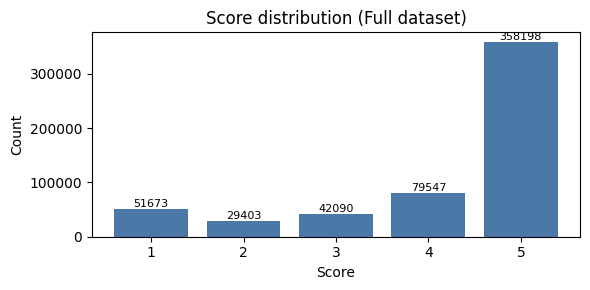

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/4
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 44s 27ms/step - accuracy: 0.5927 - loss: 1.1771 - val_accuracy: 0.5991 - val_loss: 1.0033
Epoch 2/4
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.6529 - loss: 0.9922 - val_accuracy: 0.6312 - val_loss: 0.9160
Epoch 3/4
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 40s 24ms/step - accuracy: 0.6853 - loss: 0.8743 - val_accuracy: 0.6485 - val_loss: 0.8712
Epoch 4/4
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.7103 - loss: 0.7778 - val_accuracy: 0.6818 - val_loss: 0.8122

Test: loss=0.8174  acc=0.6804

Classification report:
              precision    recall  f1-score   support

           1       0.66      0.72      0.69      7751
           2       0.44      0.50      0.47      4411
           3       0.44      0.54      0.48      6313
           4       0.35      0.59      0.44     11932
           5       0.91      0.73      0.81     53730

    accuracy                           0.68     84137
   macro avg       0.56      0.62      0.

In [7]:
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt, tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, utils

# ============= config (tune for your hardware) =============
# CSV = "Reviews.csv"   # path to attached file
# CSV = "D:\\HardDriveFiles\\Personal\\REVA\\RACE\\Semester1\\DATASETS\\DeepLearning\\Day1\\amazon_review.csv"
CSV = "//content//drive//MyDrive//Day1//amazon_review.csv"
SEED = 42; np.random.seed(SEED); tf.random.set_seed(SEED)
MAX_WORDS = 30000     # vocab size cap (increase if you have VRAM/CPU)
MAX_LEN   = 90        # sequence length (shorter = faster)
EMBED     = 100       # embedding dimension
LSTM_UNITS= 64        # per LSTM layer
EPOCHS    = 4         # quick passes; early stopping will cut if needed
BATCH     = 256       # adjust to fit memory; try 128 if OOM

# Optional: make TensorFlow GPUs behave nicer (safe to keep on CPU too)
#for gpu in tf.config.experimental.list_physical_devices('GPU'):
#    tf.config.experimental.set_memory_growth(gpu, True)

# ============= load & column detection =============
df = pd.read_csv(CSV, engine="python")
text_col = next((c for c in ["Text","text","review_text","review","body"] if c in df.columns), None)
score_col= next((c for c in ["Score","score","rating","stars","label"] if c in df.columns), None)
if text_col is None or score_col is None:
    raise ValueError(f"Missing text/score columns. Found: {df.columns.tolist()}")

# Your file has 'Text' and 'Score' columns exactly; the auto-detect here is for safety.

# ============= clean data =============
clean = lambda s: re.sub(r"\s+"," ", re.sub(r"<.*?>"," ", str(s))).strip().lower()
df = df[[text_col, score_col]].dropna()
df[score_col] = pd.to_numeric(df[score_col], errors="coerce")
df = df.dropna().astype({score_col:int})
df[text_col] = df[text_col].map(clean)

# ============= show class imbalance (full dataset) =============
counts = df[score_col].value_counts().sort_index()
print("Class counts (FULL dataset):\n", counts)
plt.figure(figsize=(6,3)); plt.bar(counts.index, counts.values, color="#4C78A8")
plt.title("Score distribution (Full dataset)"); plt.xlabel("Score"); plt.ylabel("Count")
for x,v in zip(counts.index, counts.values): plt.text(x, v, str(v), ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()

# ============= stratified splits =============
X = df[text_col].values
y = df[score_col].values
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.30, random_state=SEED, stratify=y)
X_va, X_te, y_va, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

# ============= tokenize & pad =============
tok = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tok.fit_on_texts(X_tr)
to_pad = lambda arr: pad_sequences(tok.texts_to_sequences(arr), maxlen=MAX_LEN, padding="post", truncating="post")
X_tr, X_va, X_te = to_pad(X_tr), to_pad(X_va), to_pad(X_te)

# ============= labels → categorical =============
classes = np.sort(np.unique(y))
c2i = {c:i for i,c in enumerate(classes)}; C = len(classes)
y_tr_i = np.array([c2i[v] for v in y_tr]); y_va_i = np.array([c2i[v] for v in y_va]); y_te_i = np.array([c2i[v] for v in y_te])
y_tr_oh = utils.to_categorical(y_tr_i, C); y_va_oh = utils.to_categorical(y_va_i, C); y_te_oh = utils.to_categorical(y_te_i, C)

# ============= 3‑layer LSTM model =============
model = models.Sequential([
    layers.Embedding(input_dim=min(MAX_WORDS, len(tok.word_index))+1, output_dim=EMBED,
                     input_length=MAX_LEN, mask_zero=True),
    layers.SpatialDropout1D(0.2),
    layers.LSTM(LSTM_UNITS, return_sequences=True),
    layers.LSTM(LSTM_UNITS, return_sequences=True),
    layers.LSTM(LSTM_UNITS),
    layers.Dense(C, activation="softmax")
])
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

# ============= class weights & train =============
cw = compute_class_weight(class_weight="balanced", classes=np.arange(C), y=y_tr_i)
cw = {i:w for i,w in enumerate(cw)}
es = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", mode="max", patience=2, restore_best_weights=True)
model.fit(X_tr, y_tr_oh, validation_data=(X_va, y_va_oh), epochs=EPOCHS, batch_size=BATCH,
          class_weight=cw, callbacks=[es], verbose=1)

# ============= evaluate =============
loss, acc = model.evaluate(X_te, y_te_oh, verbose=0)
print(f"\nTest: loss={loss:.4f}  acc={acc:.4f}")
pred = model.predict(X_te, verbose=0).argmax(1)

print("\nClassification report:")
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_te_i, pred, target_names=[str(c) for c in classes]))

print("\nConfusion matrix:")
print(pd.DataFrame(confusion_matrix(y_te_i, pred),
                   index=[f"true_{c}" for c in classes],
                   columns=[f"pred_{c}" for c in classes]))

# ============= quick sanity predictions =============
samples = ["Absolutely fantastic product!", "Terrible quality; very disappointed.", "It's okay, does the job."]
s_pad = to_pad(samples)
inv = {v:k for k,v in c2i.items()}
s_pred = model.predict(s_pad, verbose=0).argmax(1)
print("\nSample predictions:")
for s, p in zip(samples, s_pred): print(f"- {s}  => predicted Score: {inv[p]}")